## m6 — Up Class Rebalancing Experiments

m5c achieves 92% overall test accuracy with Up F1 of 0.74. Up remains the
weakest class due to severe imbalance (~3% of training data: 4,247 vs ~45K
for other classes). m5c already uses sqrt inverse frequency class weights
(2.87× for Up) and unfrozen CNNs.

This notebook tests four strategies to improve Up performance, each run
independently with its own checkpoint so results are directly comparable.

| Experiment | Strategy | What Changes |
|------------|----------|-------------|
| m6a | Aggressive class weights | Up weight bumped from 2.87× to manual override |
| m6b | Focal loss | Replaces CrossEntropyLoss — downweights easy examples |
| m6c | Up oversampling | Duplicates Up samples in the data stream |
| m6d | Up-targeted augmentation | Heavier photometric augmentation on Up samples only |

Val/test sets are **never** modified — only the training pipeline changes.

## Setup

In [1]:
# Install WebDataset
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.4 MB/s eta 0:00:00


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# Verify GPU
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [4]:
# Imports

import os, glob, time, math, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import webdataset as wds
from torchvision import transforms
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports loaded, device: {device}")

Imports loaded, device: cuda


In [5]:
# Paths

TAR_DIR         = "/content/gaze_wds_balanced"
LABELS_CSV      = "/content/drive/MyDrive/210/gaze_labels.csv"
GEO_PARQUET     = "/content/drive/MyDrive/210/geo_features_v1.parquet"
DRIVE_DIR       = "/content/drive/MyDrive/210"

print(f"TAR_DIR:     {TAR_DIR}")
print(f"LABELS_CSV:  {LABELS_CSV}")
print(f"GEO_PARQUET: {GEO_PARQUET}")

TAR_DIR:     /content/gaze_wds_balanced
LABELS_CSV:  /content/drive/MyDrive/210/gaze_labels.csv
GEO_PARQUET: /content/drive/MyDrive/210/geo_features_v1.parquet


In [6]:
# Copy tars to local Colab disk

for split in ['train', 'val', 'test']:
    local_dir = f'/content/gaze_wds_balanced/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    for f in tar_files:
        fname = os.path.basename(f)
        dest = f"{local_dir}/{fname}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"{split}: {count} tars copied")

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [7]:
# Verify files

train_tar_urls = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tar_urls   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tar_urls  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")
print(f"Labels CSV: {os.path.exists(LABELS_CSV)}")
print(f"Geo parquet: {os.path.exists(GEO_PARQUET)}")

Train tars: 75
Val tars:   16
Test tars:  16
Labels CSV: True
Geo parquet: True


In [8]:
# Load labels — 4-class lookup (Straight dropped)

df_labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
print(f"Loaded {len(df_labels)} labeled frames")

label_lookup = {}
for _, row in df_labels.iterrows():
    key = f"{row['subject_id']}_{int(row['frame_idx']):06d}"
    label_lookup[key] = row['label']

# filter out Straight
label_map_4 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}
label_lookup_4 = {k: v for k, v in label_lookup.items() if v != 'Straight'}

print(f"Label lookup (4-class): {len(label_lookup_4)} entries")
print(f"Dropped: {len(label_lookup) - len(label_lookup_4)} Straight samples")

Loaded 849131 labeled frames
Label lookup (4-class): 602467 entries
Dropped: 246664 Straight samples


In [9]:
# Load geo features

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    features = row[geo_cols].values.astype(np.float32)
    geo_lookup[row['key']] = features

print(f"Geo lookup: {len(geo_lookup)} entries")

# neutral default for missing samples
GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)

# coverage check
matched = sum(1 for k in label_lookup_4 if k in geo_lookup)
print(f"Geo coverage: {matched}/{len(label_lookup_4)} ({100*matched/len(label_lookup_4):.1f}%)")

Loaded geo features: 273462 rows
Geo lookup: 273462 entries
Geo coverage: 192519/602467 (32.0%)


In [10]:
# Image transforms — shared across all experiments
#
# Training: photometric augmentation (color jitter, grayscale, blur)
# Val/Test: clean (resize + normalize only)
#
# Eye images: 48x48
# Face images: 112x112 (already correct size in tars)

eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


In [11]:
# GazeNetM5 model definition
#
# Three-stream CNN (shared-weight eye CNNs + face CNN) plus geo MLP.
# Identical to m5c — architecture does not change across experiments.

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        # eye CNN — shared weights for left and right
        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # face CNN
        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # geometric feature branch
        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        # FC classifier: 4608*2 (eyes) + 2304 (face) + 64 (geo) = 11584
        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)
        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined")
_test = GazeNetM5(num_classes=4)
print(f"Parameters: {sum(p.numel() for p in _test.parameters()):,}")
del _test

GazeNetM5 defined
Parameters: 6,586,820


## Shared Dataset & Training Functions

All experiments share the same val/test loaders, model architecture, and
training loop. Each experiment only changes the **training dataloader**
and/or the **loss function**.

In [12]:
# Baseline dataset builder (same as m5c)
#
# Streams samples from WebDataset tars, joins geo features,
# drops Straight, returns dict with tensors.

def make_dataset_4class(tar_urls, eye_transform, face_transform, shuffle=True):
    """Standard 4-class WebDataset pipeline (identical to m5c)."""

    def filter_and_transform(sample):
        key = sample["__key__"]

        # skip Straight samples
        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map_4[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class defined")

make_dataset_4class defined


In [13]:
# Val/test loaders — fixed across all experiments

val_dataset  = make_dataset_4class(val_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset = make_dataset_4class(test_tar_urls, eye_transform_clean, face_transform_clean, shuffle=False)

val_loader  = wds.WebLoader(val_dataset,  batch_size=32, num_workers=2, pin_memory=True)
test_loader = wds.WebLoader(test_dataset, batch_size=32, num_workers=2, pin_memory=True)

print("Val/test loaders ready (shared across all experiments)")

Val/test loaders ready (shared across all experiments)


In [14]:
# Training and evaluation functions — shared across experiments

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns (avg_loss, accuracy)."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    n_batches = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        n_batches = batch_idx + 1

        if n_batches % 1000 == 0:
            elapsed = time.time() - epoch_start
            eta = (elapsed / n_batches) * (7000 - n_batches) / 60
            print(f"  Batch {n_batches}/~7000 - Loss: {loss.item():.4f} - ETA: {eta:.1f} min")

    return total_loss / n_batches, 100 * correct / total


def evaluate(model, loader, criterion, device):
    """Run evaluation. Returns (avg_loss, accuracy)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            n_batches += 1

    return total_loss / n_batches, 100 * correct / total


def run_experiment(experiment_name, model, train_loader, val_loader,
                   criterion, optimizer, scheduler, device,
                   num_epochs=20, patience=6):
    """
    Full training loop with early stopping.
    Saves best checkpoint to Drive as {experiment_name}.pth.
    Returns dict with training history.
    """
    checkpoint_path = f"{DRIVE_DIR}/{experiment_name}.pth"
    best_val_loss = float('inf')
    patience_counter = 0

    history = {
        'train_losses': [], 'val_losses': [],
        'train_accs': [], 'val_accs': [],
    }

    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {experiment_name}")
    print(f"  Checkpoint: {checkpoint_path}")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history['train_losses'].append(train_loss)
        history['val_losses'].append(val_loss)
        history['train_accs'].append(train_acc)
        history['val_accs'].append(val_acc)

        scheduler.step(val_loss)

        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Gap: {train_acc - val_acc:.2f}%")

        # checkpoint best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f"  Saved best model (val_loss={val_loss:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

    print(f"\nTraining complete! Best val loss: {best_val_loss:.4f}")
    return history

print("Training functions defined")

Training functions defined


In [15]:
# Test evaluation + confusion matrix — shared function

LABEL_NAMES = ['Up', 'Down', 'Left', 'Right']
TEAL_CMAP = LinearSegmentedColormap.from_list(
    'teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377']
)
TEAL_COLORS = ['#0D7377', '#14A3A8', '#45C4B0', '#9EEDE5']


def test_and_report(experiment_name, model, test_loader, device):
    """
    Load best checkpoint, run test eval, print classification report,
    plot confusion matrix. Returns (all_preds, all_labels) for comparison.
    """
    checkpoint_path = f"{DRIVE_DIR}/{experiment_name}.pth"
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap=TEAL_CMAP,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                linewidths=0.5, linecolor='white')
    plt.xlabel('Predicted', fontsize=11)
    plt.ylabel('Actual', fontsize=11)
    plt.title(f'{experiment_name} — Test Confusion Matrix',
              fontweight='bold', color='#0D7377', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\n{experiment_name} Test Performance")
    print("=" * 50)
    print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES))

    return all_preds, all_labels

print("test_and_report defined")

test_and_report defined


---

## Experiment m6a — Aggressive Class Weights

m5c uses sqrt inverse frequency, giving Up a 2.87× weight.
This experiment tests **linear inverse frequency** and a **manual
override** to push Up harder.

- sqrt inv freq (m5c baseline): Up=2.87, Down=0.82, Left=0.90, Right=0.92
- linear inv freq: Up=8.25, Down=0.68, Left=0.82, Right=0.86
- manual 6× for Up: Up=6.00, Down=1.00, Left=1.00, Right=1.00

The manual option isolates the Up weight from the others so we can
see whether the issue is insufficient Up gradient vs. too much
interference from the other class weights.

In [16]:
# !!! CHOOSE ONE WEIGHTING SCHEME BELOW BEFORE RUNNING !!!
# !!! Comment out the ones you don't want.              !!!

train_counts = [4247, 51514, 42872, 40888]  # Up, Down, Left, Right
total = sum(train_counts)
n_classes = 4

# --- Option A: linear inverse frequency ---
# weights_m6a = [total / (n_classes * c) for c in train_counts]

# --- Option B: manual 6x for Up, neutral for rest ---
weights_m6a = [6.0, 1.0, 1.0, 1.0]

weights_m6a_tensor = torch.tensor(weights_m6a, dtype=torch.float32).to(device)

print("m6a class weights:")
for name, w in zip(LABEL_NAMES, weights_m6a):
    print(f"  {name:6s}: {w:.3f}")

m6a class weights:
  Up    : 6.000
  Down  : 1.000
  Left  : 1.000
  Right : 1.000


In [17]:
# m6a setup — aggressive weights, everything else identical to m5c

model_m6a = GazeNetM5(num_classes=4).to(device)

criterion_m6a = nn.CrossEntropyLoss(
    weight=weights_m6a_tensor,
    label_smoothing=0.1
)

optimizer_m6a = torch.optim.Adam(model_m6a.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler_m6a = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m6a, mode='min', patience=3, factor=0.5
)

# standard train loader (same data pipeline as m5c)
train_dataset_m6a = make_dataset_4class(
    train_tar_urls, eye_transform_aug, face_transform_aug, shuffle=True
)
train_loader_m6a = wds.WebLoader(
    train_dataset_m6a, batch_size=32, num_workers=2, pin_memory=True
)

print("m6a ready to train")

m6a ready to train


In [18]:
# m6a training

history_m6a = run_experiment(
    experiment_name='m6a',
    model=model_m6a,
    train_loader=train_loader_m6a,
    val_loader=val_loader,
    criterion=criterion_m6a,
    optimizer=optimizer_m6a,
    scheduler=scheduler_m6a,
    device=device,
)


  EXPERIMENT: m6a
  Checkpoint: /content/drive/MyDrive/210/m6a.pth

Epoch 1/20
  Batch 1000/~7000 - Loss: 0.9956 - ETA: 13.3 min
  Batch 2000/~7000 - Loss: 0.9911 - ETA: 11.0 min
  Batch 3000/~7000 - Loss: 0.5460 - ETA: 8.5 min
  Batch 4000/~7000 - Loss: 0.7669 - ETA: 6.2 min
  Train Loss: 0.9105 | Train Acc: 83.78%
  Val Loss:   0.8459 | Val Acc:   89.61%
  Gap: -5.83%
  Saved best model (val_loss=0.8459)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.8331 - ETA: 13.3 min
  Batch 2000/~7000 - Loss: 0.8730 - ETA: 11.0 min
  Batch 3000/~7000 - Loss: 0.7444 - ETA: 8.5 min
  Batch 4000/~7000 - Loss: 0.5452 - ETA: 6.3 min
  Train Loss: 0.7614 | Train Acc: 92.43%
  Val Loss:   0.8221 | Val Acc:   90.57%
  Gap: 1.85%
  Saved best model (val_loss=0.8221)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.7459 - ETA: 13.2 min
  Batch 2000/~7000 - Loss: 0.7492 - ETA: 11.0 min
  Batch 3000/~7000 - Loss: 0.6285 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.5457 - ETA: 6.3 min
  Train Loss: 0.7226 | Train Acc: 94.

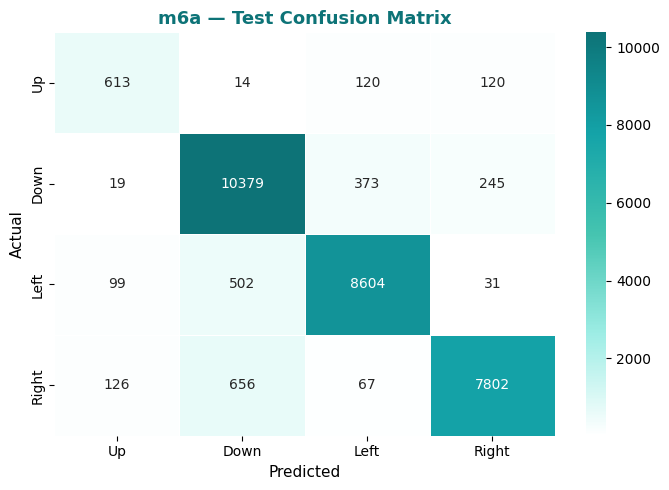


m6a Test Performance
              precision    recall  f1-score   support

          Up       0.72      0.71      0.71       867
        Down       0.90      0.94      0.92     11016
        Left       0.94      0.93      0.94      9236
       Right       0.95      0.90      0.93      8651

    accuracy                           0.92     29770
   macro avg       0.88      0.87      0.87     29770
weighted avg       0.92      0.92      0.92     29770



In [19]:
# m6a test evaluation

preds_m6a, labels_m6a = test_and_report('m6a', model_m6a, test_loader, device)

---

## Experiment m6b — Focal Loss

Focal loss adds a modulating factor $(1 - p_t)^\gamma$ to standard
cross-entropy. When the model is confident on a sample ($p_t$ is high),
the loss contribution shrinks — effectively concentrating learning on
hard, uncertain samples.

Since Down/Left/Right are already at 95%+ recall, most of their gradient
is wasted on samples the model has already learned. Focal loss redirects
that capacity toward the harder Up boundary cases.

We keep the m5c sqrt inverse frequency class weights and **add** focal
loss on top so the two mechanisms complement each other.

In [20]:
# Focal loss implementation
#
# Combines per-class weights (alpha) with focal modulation (gamma).
# gamma=0 recovers standard weighted cross-entropy.
# gamma=2 is the original paper default — aggressive downweighting
# of easy examples.

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0, reduction='mean'):
        """
        Args:
            alpha: per-class weight tensor, shape (num_classes,).
                   None means no class weighting.
            gamma: focal modulation exponent. 0 = standard CE.
            label_smoothing: standard label smoothing factor.
            reduction: 'mean' or 'sum' or 'none'.
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        # standard cross-entropy per sample (no reduction)
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.alpha,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )

        # p_t = probability assigned to the correct class
        log_probs = F.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        p_t = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # focal modulation: (1 - p_t)^gamma
        focal_weight = (1.0 - p_t) ** self.gamma
        loss = focal_weight * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

print("FocalLoss defined")

FocalLoss defined


In [21]:
# m6b setup — focal loss with m5c sqrt inverse frequency weights

model_m6b = GazeNetM5(num_classes=4).to(device)

# same sqrt inverse freq weights as m5c
train_counts = [4247, 51514, 42872, 40888]
total = sum(train_counts)
n_classes = 4
weights_m5c = [math.sqrt(total / (n_classes * c)) for c in train_counts]
weights_m5c_tensor = torch.tensor(weights_m5c, dtype=torch.float32).to(device)

# !!! gamma controls how aggressively easy samples are downweighted.
# !!! gamma=2.0 is the paper default. Try 1.0 for a milder effect.
FOCAL_GAMMA = 2.0

criterion_m6b = FocalLoss(
    alpha=weights_m5c_tensor,
    gamma=FOCAL_GAMMA,
    label_smoothing=0.1
)

optimizer_m6b = torch.optim.Adam(model_m6b.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler_m6b = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m6b, mode='min', patience=3, factor=0.5
)

# standard train loader
train_dataset_m6b = make_dataset_4class(
    train_tar_urls, eye_transform_aug, face_transform_aug, shuffle=True
)
train_loader_m6b = wds.WebLoader(
    train_dataset_m6b, batch_size=32, num_workers=2, pin_memory=True
)

print(f"m6b ready — FocalLoss(gamma={FOCAL_GAMMA}) + sqrt inv freq weights")

m6b ready — FocalLoss(gamma=2.0) + sqrt inv freq weights


In [22]:
# m6b training

history_m6b = run_experiment(
    experiment_name='m6b',
    model=model_m6b,
    train_loader=train_loader_m6b,
    val_loader=val_loader,
    criterion=criterion_m6b,
    optimizer=optimizer_m6b,
    scheduler=scheduler_m6b,
    device=device,
)


  EXPERIMENT: m6b
  Checkpoint: /content/drive/MyDrive/210/m6b.pth

Epoch 1/20
  Batch 1000/~7000 - Loss: 0.1518 - ETA: 13.4 min
  Batch 2000/~7000 - Loss: 0.1839 - ETA: 11.1 min
  Batch 3000/~7000 - Loss: 0.1262 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.1104 - ETA: 6.3 min
  Train Loss: 0.2288 | Train Acc: 83.21%
  Val Loss:   0.1457 | Val Acc:   90.21%
  Gap: -7.00%
  Saved best model (val_loss=0.1457)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.3467 - ETA: 13.2 min
  Batch 2000/~7000 - Loss: 0.2085 - ETA: 11.1 min
  Batch 3000/~7000 - Loss: 0.1229 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.0691 - ETA: 6.3 min
  Train Loss: 0.1131 | Train Acc: 92.05%
  Val Loss:   0.1336 | Val Acc:   90.17%
  Gap: 1.88%
  Saved best model (val_loss=0.1336)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.1194 - ETA: 13.3 min
  Batch 2000/~7000 - Loss: 0.0931 - ETA: 11.1 min
  Batch 3000/~7000 - Loss: 0.0724 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.1033 - ETA: 6.3 min
  Train Loss: 0.0878 | Train Acc: 93.

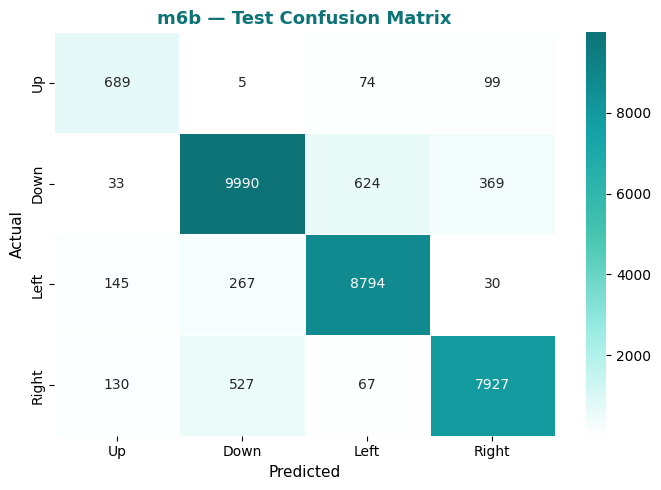


m6b Test Performance
              precision    recall  f1-score   support

          Up       0.69      0.79      0.74       867
        Down       0.93      0.91      0.92     11016
        Left       0.92      0.95      0.94      9236
       Right       0.94      0.92      0.93      8651

    accuracy                           0.92     29770
   macro avg       0.87      0.89      0.88     29770
weighted avg       0.92      0.92      0.92     29770



In [23]:
# m6b test evaluation

preds_m6b, labels_m6b = test_and_report('m6b', model_m6b, test_loader, device)

---

## Experiment m6c — Up Oversampling in Stream

WebDataset is a streaming format, so we can't use PyTorch's
`WeightedRandomSampler`. Instead, we use a `.compose()` stage
that buffers Up samples and re-yields each one `REPEAT_FACTOR`
times with fresh augmentation per copy.

With `REPEAT_FACTOR=8`, the 4,247 Up samples become ~33,976 —
roughly comparable to the ~42K-51K of other classes.

Combined with m5c's sqrt inverse frequency class weights.

In [24]:
# Up-oversampling dataset builder
#
# Key insight: we repeat the raw PIL images (before augmentation)
# and apply transforms independently per copy. Each copy gets a
# different random augmentation (color jitter, blur, etc.) so the
# model sees genuinely different training signal, not identical
# duplicates.

# !!! How many times to repeat each Up sample.
# !!! 8x brings ~4K Up to ~34K, roughly matching other classes.
# !!! 10x would overshoot to ~42K. Adjust and observe.
UP_REPEAT_FACTOR = 8

def make_dataset_4class_upsample_up(
    tar_urls, eye_transform, face_transform, repeat_factor, shuffle=True
):
    """
    Same as make_dataset_4class, but Up samples (label_idx=0) are
    yielded `repeat_factor` times. Each copy gets fresh augmentation
    since transforms are applied per-yield.
    """

    def _transform_sample(key, face_pil, left_pil, right_pil):
        """Apply transforms to raw PIL images and build output dict."""
        face = np.array(face_pil)
        left_eye = np.array(left_pil)
        right_eye = np.array(right_pil)

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map_4[label_lookup_4[key]]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    def up_repeat_stage(src):
        """Compose stage that repeats Up samples with fresh augmentation."""
        for sample in src:
            key = sample["__key__"]

            # skip samples not in our 4-class set
            label_str = label_lookup_4.get(key)
            if label_str is None:
                continue

            # keep raw PIL images for re-augmentation
            face_pil = sample["face.jpg"]
            left_pil = sample["left.jpg"]
            right_pil = sample["right.jpg"]

            label_idx = label_map_4[label_str]

            if label_idx == 0:  # Up class
                # yield repeat_factor copies, each freshly augmented
                for _ in range(repeat_factor):
                    yield _transform_sample(key, face_pil, left_pil, right_pil)
            else:
                # non-Up: yield once as normal
                yield _transform_sample(key, face_pil, left_pil, right_pil)

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .compose(up_repeat_stage)
    )

    return dataset

print(f"make_dataset_4class_upsample_up defined (repeat_factor={UP_REPEAT_FACTOR})")

make_dataset_4class_upsample_up defined (repeat_factor=8)


In [25]:
# m6c setup — oversampled Up + sqrt inverse frequency weights

model_m6c = GazeNetM5(num_classes=4).to(device)

# !!! We keep class weights here. The oversampling increases Up
# !!! frequency, the weights adjust gradient magnitude. They
# !!! address different parts of the problem.
# !!!
# !!! If Up starts overfitting, try reducing weights to [1,1,1,1]
# !!! and let oversampling alone handle the imbalance.
criterion_m6c = nn.CrossEntropyLoss(
    weight=weights_m5c_tensor,
    label_smoothing=0.1
)

optimizer_m6c = torch.optim.Adam(model_m6c.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler_m6c = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m6c, mode='min', patience=3, factor=0.5
)

# oversampled train loader
train_dataset_m6c = make_dataset_4class_upsample_up(
    train_tar_urls, eye_transform_aug, face_transform_aug,
    repeat_factor=UP_REPEAT_FACTOR, shuffle=True
)
train_loader_m6c = wds.WebLoader(
    train_dataset_m6c, batch_size=32, num_workers=2, pin_memory=True
)

print(f"m6c ready — Up oversampled {UP_REPEAT_FACTOR}x + sqrt inv freq weights")

m6c ready — Up oversampled 8x + sqrt inv freq weights


In [26]:
# m6c training

history_m6c = run_experiment(
    experiment_name='m6c',
    model=model_m6c,
    train_loader=train_loader_m6c,
    val_loader=val_loader,
    criterion=criterion_m6c,
    optimizer=optimizer_m6c,
    scheduler=scheduler_m6c,
    device=device,
)


  EXPERIMENT: m6c
  Checkpoint: /content/drive/MyDrive/210/m6c.pth

Epoch 1/20
  Batch 1000/~7000 - Loss: 0.6577 - ETA: 13.2 min
  Batch 2000/~7000 - Loss: 0.4508 - ETA: 10.8 min
  Batch 3000/~7000 - Loss: 0.8709 - ETA: 8.5 min
  Batch 4000/~7000 - Loss: 0.6660 - ETA: 6.2 min
  Batch 5000/~7000 - Loss: 0.3183 - ETA: 4.1 min
  Train Loss: 0.7160 | Train Acc: 81.29%
  Val Loss:   0.7748 | Val Acc:   86.34%
  Gap: -5.06%
  Saved best model (val_loss=0.7748)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.6690 - ETA: 13.1 min
  Batch 2000/~7000 - Loss: 0.6915 - ETA: 10.8 min
  Batch 3000/~7000 - Loss: 0.9044 - ETA: 8.4 min
  Batch 4000/~7000 - Loss: 0.3690 - ETA: 6.2 min
  Batch 5000/~7000 - Loss: 0.4876 - ETA: 4.1 min
  Train Loss: 0.5628 | Train Acc: 90.48%
  Val Loss:   0.7306 | Val Acc:   88.57%
  Gap: 1.92%
  Saved best model (val_loss=0.7306)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.7518 - ETA: 13.2 min
  Batch 2000/~7000 - Loss: 0.6841 - ETA: 10.8 min
  Batch 3000/~7000 - Loss: 0.6521 - E

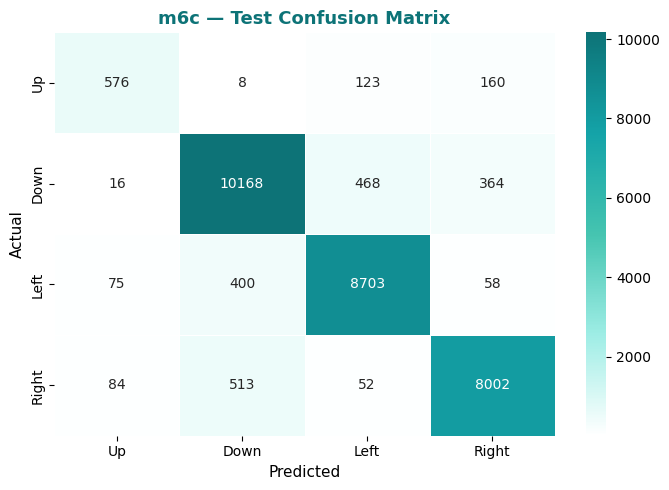


m6c Test Performance
              precision    recall  f1-score   support

          Up       0.77      0.66      0.71       867
        Down       0.92      0.92      0.92     11016
        Left       0.93      0.94      0.94      9236
       Right       0.93      0.92      0.93      8651

    accuracy                           0.92     29770
   macro avg       0.89      0.86      0.87     29770
weighted avg       0.92      0.92      0.92     29770



In [27]:
# m6c test evaluation

preds_m6c, labels_m6c = test_and_report('m6c', model_m6c, test_loader, device)

---

## Experiment m6d — Up-Targeted Augmentation

All classes currently get the same photometric augmentation.
This experiment applies **heavier** augmentation to Up samples
only — more aggressive color jitter, higher grayscale/blur
probability — to squeeze more diversity from the small Up pool.

The augmentations are strictly photometric (no spatial transforms)
to preserve the iris-position and head-pose signals that the geo
features depend on.

Non-Up samples get the standard m5c augmentation.
Combined with m5c's sqrt inverse frequency class weights.

In [28]:
# Heavier photometric transforms for Up samples only
#
# What's different vs. standard aug:
#   - color jitter cranked up (brightness 0.5 vs 0.3, etc.)
#   - grayscale probability doubled (0.2 vs 0.1)
#   - blur sigma range widened
#   - added random posterize and random adjust sharpness
#
# What's intentionally NOT here:
#   - no horizontal flips (swaps left/right semantics)
#   - no spatial transforms (would break geo feature alignment)
#   - no vertical flips (would invert up/down semantics)

eye_transform_up_heavy = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.05),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.3),
    transforms.RandomPosterize(bits=4, p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_up_heavy = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.05),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.3),
    transforms.RandomPosterize(bits=4, p=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Up-heavy transforms defined")

Up-heavy transforms defined


In [29]:
# Up-targeted augmentation dataset builder
#
# Routes each sample to the appropriate transform set based
# on its class label: heavy aug for Up, standard for everything else.

def make_dataset_4class_up_targeted_aug(
    tar_urls,
    eye_transform_standard, face_transform_standard,
    eye_transform_up, face_transform_up,
    shuffle=True
):
    """4-class pipeline with class-conditional augmentation."""

    def filter_and_transform(sample):
        key = sample["__key__"]

        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        label_idx = label_map_4[label_str]

        # pick transform set based on class
        if label_idx == 0:  # Up
            e_tfm = eye_transform_up
            f_tfm = face_transform_up
        else:
            e_tfm = eye_transform_standard
            f_tfm = face_transform_standard

        left_eye = e_tfm(left_eye)
        right_eye = e_tfm(right_eye)
        face = f_tfm(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class_up_targeted_aug defined")

make_dataset_4class_up_targeted_aug defined


In [30]:
# m6d setup — up-targeted augmentation + sqrt inverse frequency weights

model_m6d = GazeNetM5(num_classes=4).to(device)

criterion_m6d = nn.CrossEntropyLoss(
    weight=weights_m5c_tensor,
    label_smoothing=0.1
)

optimizer_m6d = torch.optim.Adam(model_m6d.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler_m6d = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m6d, mode='min', patience=3, factor=0.5
)

# class-conditional augmentation loader
train_dataset_m6d = make_dataset_4class_up_targeted_aug(
    train_tar_urls,
    eye_transform_standard=eye_transform_aug,
    face_transform_standard=face_transform_aug,
    eye_transform_up=eye_transform_up_heavy,
    face_transform_up=face_transform_up_heavy,
    shuffle=True
)
train_loader_m6d = wds.WebLoader(
    train_dataset_m6d, batch_size=32, num_workers=2, pin_memory=True
)

print("m6d ready — Up-targeted augmentation + sqrt inv freq weights")

m6d ready — Up-targeted augmentation + sqrt inv freq weights


In [31]:
# m6d training

history_m6d = run_experiment(
    experiment_name='m6d',
    model=model_m6d,
    train_loader=train_loader_m6d,
    val_loader=val_loader,
    criterion=criterion_m6d,
    optimizer=optimizer_m6d,
    scheduler=scheduler_m6d,
    device=device,
)


  EXPERIMENT: m6d
  Checkpoint: /content/drive/MyDrive/210/m6d.pth

Epoch 1/20
  Batch 1000/~7000 - Loss: 0.7227 - ETA: 13.5 min
  Batch 2000/~7000 - Loss: 0.8323 - ETA: 11.2 min
  Batch 3000/~7000 - Loss: 0.6935 - ETA: 8.7 min
  Batch 4000/~7000 - Loss: 0.6605 - ETA: 6.4 min
  Train Loss: 0.8043 | Train Acc: 85.36%
  Val Loss:   0.7188 | Val Acc:   89.19%
  Gap: -3.83%
  Saved best model (val_loss=0.7188)

Epoch 2/20
  Batch 1000/~7000 - Loss: 0.6528 - ETA: 13.5 min
  Batch 2000/~7000 - Loss: 0.6231 - ETA: 11.2 min
  Batch 3000/~7000 - Loss: 0.5986 - ETA: 8.7 min
  Batch 4000/~7000 - Loss: 0.5878 - ETA: 6.4 min
  Train Loss: 0.6549 | Train Acc: 93.06%
  Val Loss:   0.6806 | Val Acc:   91.52%
  Gap: 1.54%
  Saved best model (val_loss=0.6806)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.6263 - ETA: 13.5 min
  Batch 2000/~7000 - Loss: 0.7114 - ETA: 11.2 min
  Batch 3000/~7000 - Loss: 0.6219 - ETA: 8.6 min
  Batch 4000/~7000 - Loss: 0.5652 - ETA: 6.3 min
  Train Loss: 0.6147 | Train Acc: 94.

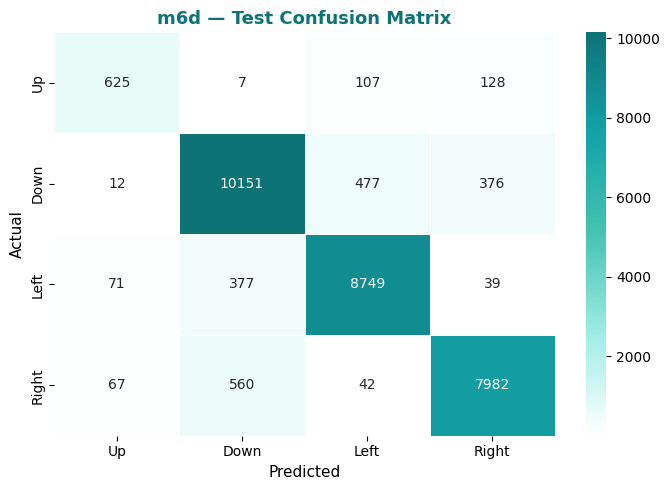


m6d Test Performance
              precision    recall  f1-score   support

          Up       0.81      0.72      0.76       867
        Down       0.91      0.92      0.92     11016
        Left       0.93      0.95      0.94      9236
       Right       0.94      0.92      0.93      8651

    accuracy                           0.92     29770
   macro avg       0.90      0.88      0.89     29770
weighted avg       0.92      0.92      0.92     29770



In [32]:
# m6d test evaluation

preds_m6d, labels_m6d = test_and_report('m6d', model_m6d, test_loader, device)

---

## Experiment Comparison

Side-by-side comparison of all experiments against the m5c baseline.
The key metric is **Up F1** — overall accuracy may not move much
since Up is only 3% of the data.

In [33]:
# Compare Up F1 and overall accuracy across experiments
#
# m5c baseline numbers (from prior notebook run):
#   Overall accuracy: ~92%
#   Up F1: 0.74

from sklearn.metrics import f1_score, accuracy_score

# m5c baseline — hardcoded from prior run
# !!! Update these if you re-run m5c or if they differ from your records
m5c_overall_acc = 92.1   # approximate, update from your spreadsheet
m5c_up_f1 = 0.74         # from m5c classification report

results = {
    'm5c (baseline)': {'acc': m5c_overall_acc, 'up_f1': m5c_up_f1},
}

# compute metrics for each experiment that was run
for name, preds, labels in [
    ('m6a', preds_m6a, labels_m6a),
    ('m6b', preds_m6b, labels_m6b),
    ('m6c', preds_m6c, labels_m6c),
    ('m6d', preds_m6d, labels_m6d),
]:
    try:
        acc = 100 * accuracy_score(labels, preds)
        # Up = class 0, compute its F1 from the per-class report
        f1s = f1_score(labels, preds, average=None, labels=[0, 1, 2, 3])
        results[name] = {'acc': acc, 'up_f1': f1s[0]}
    except NameError:
        # experiment wasn't run yet
        print(f"  {name}: not yet run, skipping")

# print comparison table
print(f"{'Experiment':<20s} {'Overall Acc':>12s} {'Up F1':>8s} {'Up F1 Δ':>9s}")
print("-" * 52)
for name, metrics in results.items():
    delta = metrics['up_f1'] - m5c_up_f1
    delta_str = f"{delta:+.3f}" if name != 'm5c (baseline)' else '  --'
    print(f"{name:<20s} {metrics['acc']:>11.2f}% {metrics['up_f1']:>8.3f} {delta_str:>9s}")

Experiment            Overall Acc    Up F1   Up F1 Δ
----------------------------------------------------
m5c (baseline)             92.10%    0.740        --
m6a                        92.03%    0.711    -0.029
m6b                        92.04%    0.739    -0.001
m6c                        92.20%    0.712    -0.028
m6d                        92.40%    0.761    +0.021


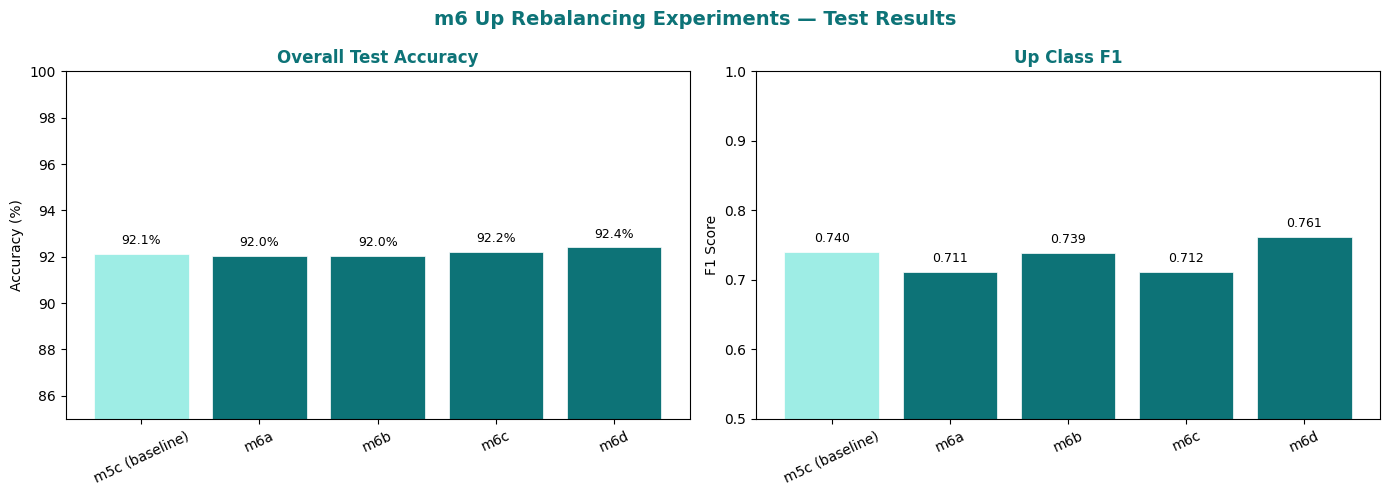

In [34]:
# Visual comparison — Up F1 bar chart

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
accs = [results[n]['acc'] for n in names]
up_f1s = [results[n]['up_f1'] for n in names]

# assign teal shades: baseline gets lightest, experiments get progressively darker
bar_colors = ['#9EEDE5'] + ['#0D7377'] * (len(names) - 1)

# overall accuracy
bars1 = axes[0].bar(names, accs, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Overall Test Accuracy', fontweight='bold', color='#0D7377')
axes[0].set_ylim(85, 100)
for bar, v in zip(bars1, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=25)

# Up F1
bars2 = axes[1].bar(names, up_f1s, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Up Class F1', fontweight='bold', color='#0D7377')
axes[1].set_ylim(0.5, 1.0)
for bar, v in zip(bars2, up_f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('m6 Up Rebalancing Experiments — Test Results',
             fontsize=14, fontweight='bold', color='#0D7377')
plt.tight_layout()
plt.show()

In [35]:
# Save raw training histories for your spreadsheet

for name, hist in [('m6a', history_m6a), ('m6b', history_m6b),
                    ('m6c', history_m6c), ('m6d', history_m6d)]:
    try:
        print(f"\n--- {name} ---")
        print(f"train_losses_{name} = {hist['train_losses']}")
        print(f"val_losses_{name} = {hist['val_losses']}")
        print(f"train_acc_{name} = {hist['train_accs']}")
        print(f"val_acc_{name} = {hist['val_accs']}")
    except NameError:
        print(f"  {name}: not yet run")


--- m6a ---
train_losses_m6a = [0.9105298188240587, 0.761371973976305, 0.7225836761786123, 0.7011558342638762, 0.6873317215044109, 0.6782001287216606, 0.6694576406705764, 0.6630753747669553, 0.6446585550791516, 0.6403452445951741]
val_losses_m6a = [0.8458970248867563, 0.8221409208356998, 0.80297062564536, 0.8014731988563376, 0.8179350539284237, 0.8191418007437119, 0.8236446796079814, 0.80818104334807, 0.8153290772337024, 0.8165347681459734]
train_acc_m6a = [83.7823696791164, 92.42551300521069, 94.23599314798489, 95.20573963776063, 95.8558209875216, 96.23999254592499, 96.63993233993449, 96.93522838855799, 97.84978605371235, 98.08129242192932]
val_acc_m6a = [89.61176720175376, 90.57350965278269, 90.7149423661693, 91.37260448341702, 90.87758998656389, 90.75030054451595, 89.99717134573227, 91.36906866558235, 90.91294816491055, 91.06498833180115]

--- m6b ---
train_losses_m6b = [0.2288411706540801, 0.11314836581064847, 0.08781633410883422, 0.07222601427420942, 0.06367502312097555, 0.057112

In [1]:
# m6 training curves — hardcoded from run

import matplotlib.pyplot as plt

TEAL_DARK  = '#0D7377'
TEAL_LIGHT = '#45C4B0'

m6_histories = {
    'm6a — aggressive class weights': {
        'tl': [0.911,0.761,0.723,0.701,0.687,0.678,0.669,0.663,0.645,0.640],
        'vl': [0.846,0.822,0.803,0.801,0.818,0.819,0.824,0.808,0.815,0.817],
        'ta': [83.78,92.43,94.24,95.21,95.86,96.24,96.64,96.94,97.85,98.08],
        'va': [89.61,90.57,90.71,91.37,90.88,90.75,90.00,91.37,90.91,91.06],
    },
    'm6b — focal loss': {
        'tl': [0.229,0.113,0.088,0.072,0.064,0.057,0.053,0.048,0.045,0.032,0.029],
        'vl': [0.146,0.134,0.121,0.121,0.118,0.142,0.175,0.140,0.160,0.152,0.161],
        'ta': [83.21,92.05,93.93,95.02,95.57,96.10,96.38,96.76,96.88,97.84,98.07],
        'va': [90.21,90.17,92.04,91.38,92.22,91.14,89.72,91.77,90.80,90.86,90.85],
    },
    'm6c — Up oversampling 8x': {
        'tl': [0.716,0.563,0.518,0.494,0.479,0.466,0.458,0.451,0.446,0.443,0.440,0.436,0.432,0.431,0.428,0.415,0.412],
        'vl': [0.775,0.731,0.694,0.696,0.682,0.699,0.693,0.665,0.690,0.666,0.661,0.665,0.671,0.669,0.680,0.678,0.677],
        'ta': [81.29,90.48,92.86,94.19,95.08,95.61,96.08,96.40,96.68,96.94,97.02,97.29,97.44,97.55,97.64,98.47,98.61],
        'va': [86.34,88.57,90.09,89.64,90.94,89.93,90.40,92.04,90.49,92.05,92.58,91.86,91.74,91.57,91.08,91.61,91.94],
    },
    'm6d — heavy Up augmentation': {
        'tl': [0.804,0.655,0.615,0.595,0.582,0.572,0.564,0.558,0.553,0.549,0.546,0.529,0.526],
        'vl': [0.719,0.681,0.684,0.664,0.673,0.663,0.661,0.667,0.680,0.668,0.698,0.677,0.678],
        'ta': [85.36,93.06,94.86,95.73,96.25,96.63,96.98,97.20,97.45,97.65,97.80,98.56,98.69],
        'va': [89.19,91.52,90.88,91.93,91.33,92.26,92.42,91.91,91.26,92.06,90.85,91.74,91.91],
    },
}

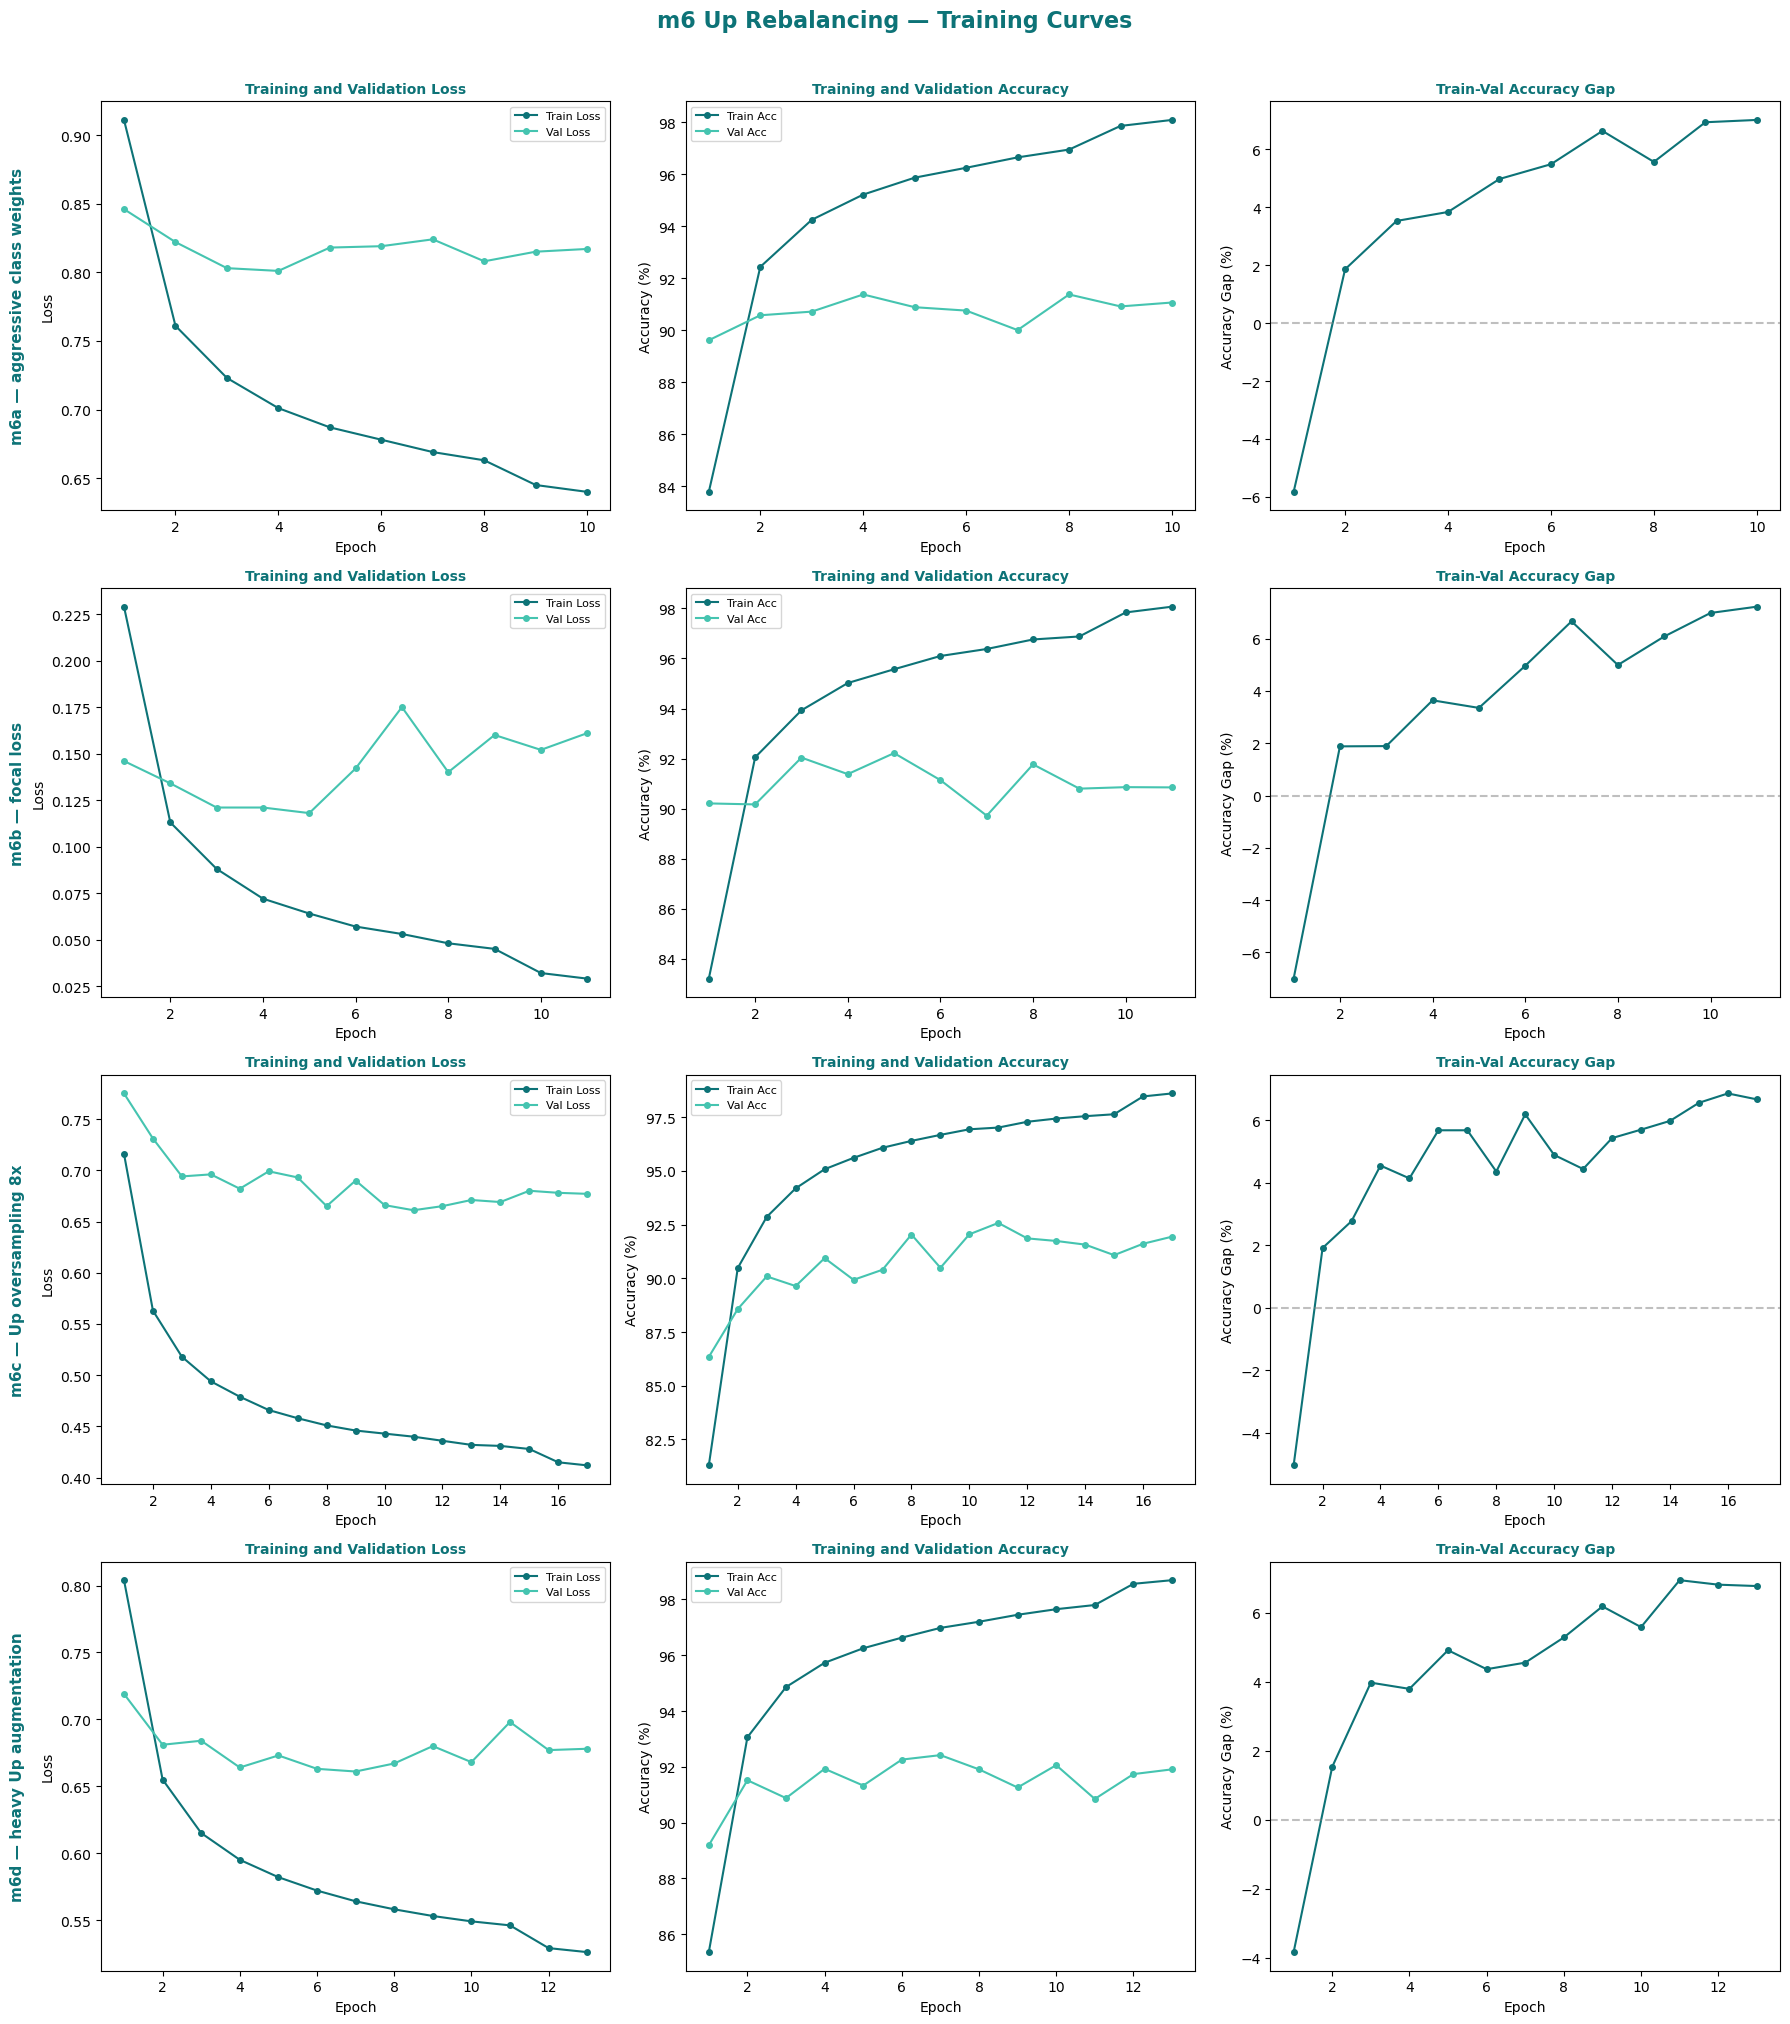

In [2]:
# Plot m6 training curves — 4 rows x 3 columns

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

for row, (name, h) in enumerate(m6_histories.items()):
    epochs = range(1, len(h['tl']) + 1)
    gaps = [t - v for t, v in zip(h['ta'], h['va'])]

    # loss
    axes[row][0].plot(epochs, h['tl'], 'o-', color=TEAL_DARK,  markersize=4, label='Train Loss')
    axes[row][0].plot(epochs, h['vl'], 'o-', color=TEAL_LIGHT, markersize=4, label='Val Loss')
    axes[row][0].set_ylabel('Loss')
    axes[row][0].set_title('Training and Validation Loss', fontweight='bold', color=TEAL_DARK, fontsize=10)
    axes[row][0].legend(fontsize=8)

    # accuracy
    axes[row][1].plot(epochs, h['ta'], 'o-', color=TEAL_DARK,  markersize=4, label='Train Acc')
    axes[row][1].plot(epochs, h['va'], 'o-', color=TEAL_LIGHT, markersize=4, label='Val Acc')
    axes[row][1].set_ylabel('Accuracy (%)')
    axes[row][1].set_title('Training and Validation Accuracy', fontweight='bold', color=TEAL_DARK, fontsize=10)
    axes[row][1].legend(fontsize=8)

    # gap
    axes[row][2].plot(epochs, gaps, 'o-', color=TEAL_DARK, markersize=4)
    axes[row][2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[row][2].set_ylabel('Accuracy Gap (%)')
    axes[row][2].set_title('Train-Val Accuracy Gap', fontweight='bold', color=TEAL_DARK, fontsize=10)

    # row label on the left
    axes[row][0].annotate(name, xy=(0, 0.5), xytext=(-60, 0),
                          xycoords='axes fraction', textcoords='offset points',
                          fontsize=11, fontweight='bold', color=TEAL_DARK,
                          rotation=90, va='center', ha='center')

    for col in range(3):
        axes[row][col].set_xlabel('Epoch')

plt.suptitle('m6 Up Rebalancing — Training Curves',
             fontsize=16, fontweight='bold', color=TEAL_DARK, y=1.01)
plt.tight_layout()
plt.show()

In [3]:
# m6 training summaries

for name, h in m6_histories.items():
    n = len(h['tl'])
    best_vl = min(h['vl'])
    best_vl_epoch = h['vl'].index(best_vl) + 1
    best_va = max(h['va'])
    best_va_epoch = h['va'].index(best_va) + 1

    print(f"\n{'='*50}")
    print(f"{name} — Training Summary")
    print(f"{'='*50}")
    print(f"Total epochs completed: {n}")
    print(f"Best validation loss: {best_vl:.4f} (Epoch {best_vl_epoch})")
    print(f"Best validation accuracy: {best_va:.2f}% (Epoch {best_va_epoch})")
    print(f"Final train accuracy: {h['ta'][-1]:.2f}%")
    print(f"Final val accuracy: {h['va'][-1]:.2f}%")
    print(f"Final train-val gap: {h['ta'][-1] - h['va'][-1]:.2f}%")


m6a — aggressive class weights — Training Summary
Total epochs completed: 10
Best validation loss: 0.8010 (Epoch 4)
Best validation accuracy: 91.37% (Epoch 4)
Final train accuracy: 98.08%
Final val accuracy: 91.06%
Final train-val gap: 7.02%

m6b — focal loss — Training Summary
Total epochs completed: 11
Best validation loss: 0.1180 (Epoch 5)
Best validation accuracy: 92.22% (Epoch 5)
Final train accuracy: 98.07%
Final val accuracy: 90.85%
Final train-val gap: 7.22%

m6c — Up oversampling 8x — Training Summary
Total epochs completed: 17
Best validation loss: 0.6610 (Epoch 11)
Best validation accuracy: 92.58% (Epoch 11)
Final train accuracy: 98.61%
Final val accuracy: 91.94%
Final train-val gap: 6.67%

m6d — heavy Up augmentation — Training Summary
Total epochs completed: 13
Best validation loss: 0.6610 (Epoch 7)
Best validation accuracy: 92.42% (Epoch 7)
Final train accuracy: 98.69%
Final val accuracy: 91.91%
Final train-val gap: 6.78%
